In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [2]:
np.random.seed(42)

timestamps = pd.date_range(
    start="2026-01-01",
    periods=1000,
    freq="h"
)

data = []

for timestamp in timestamps:
    hour = timestamp.hour
    day_of_week = timestamp.dayofweek

    # Higher occupancy during weekday working hours
    if 9 <= hour <= 18 and day_of_week < 5:
        occupancy = np.random.randint(10, 40)
    else:
        occupancy = np.random.randint(0, 5)

    temperature = np.random.uniform(22, 34)
    humidity = np.random.uniform(45, 75)
    light_level = np.random.uniform(200, 800)

    energy_kwh = (
        3
        + occupancy * 0.18
        + max(temperature - 24, 0) * 0.8
        + light_level * 0.003
        + np.random.normal(0, 0.8)
    )

    data.append([
        timestamp,
        temperature,
        humidity,
        occupancy,
        light_level,
        max(energy_kwh, 1)
    ])

df = pd.DataFrame(
    data,
    columns=[
        "timestamp",
        "temperature",
        "humidity",
        "occupancy",
        "light_level",
        "energy_kwh"
    ]
)

df.head()

,timestamp,temperature,humidity,occupancy,light_level,energy_kwh
0,2026-01-01 00:00:00,33.408572,66.959818,3,559.195091,12.557120
1,2026-01-01 01:00:00,27.510987,55.011258,2,285.720091,6.838640
2,2026-01-01 02:00:00,22.247014,74.097296,2,699.465584,4.993694
3,2026-01-01 03:00:00,29.409778,63.349595,4,204.239783,8.240406
4,2026-01-01 04:00:00,25.494750,63.355587,0,283.696316,4.320469


In [3]:
df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek

features = [
    "temperature",
    "humidity",
    "occupancy",
    "light_level",
    "hour",
    "day_of_week"
]

X = df[features]
y = df["energy_kwh"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (800, 6)
Testing data shape: (200, 6)


In [4]:
model = RandomForestRegressor(
    n_estimators=150,
    random_state=42
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"Mean Absolute Error: {mae:.2f} kWh")
print(f"R² Score: {r2:.2f}")

Mean Absolute Error: 0.72 kWh
R² Score: 0.94


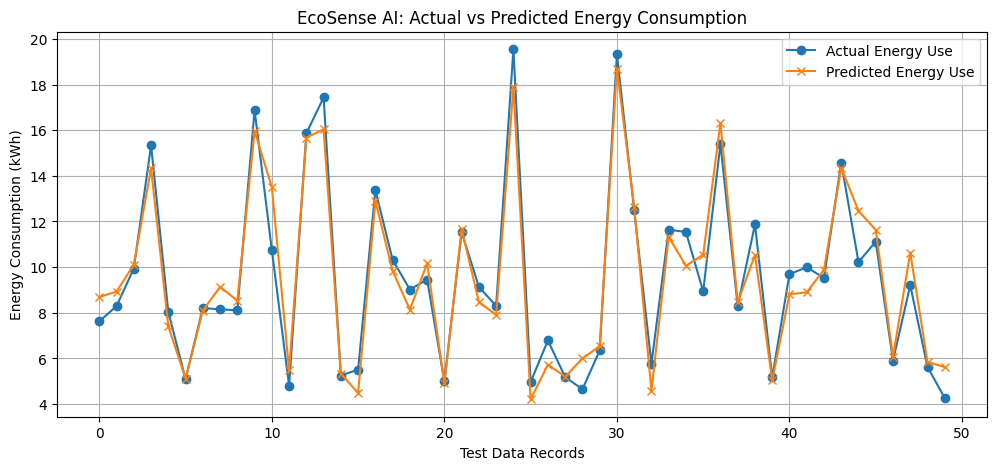

In [5]:
plt.figure(figsize=(12, 5))

plt.plot(
    y_test.values[:50],
    label="Actual Energy Use",
    marker="o"
)

plt.plot(
    predictions[:50],
    label="Predicted Energy Use",
    marker="x"
)

plt.title("EcoSense AI: Actual vs Predicted Energy Consumption")
plt.xlabel("Test Data Records")
plt.ylabel("Energy Consumption (kWh)")
plt.legend()
plt.grid(True)

plt.show()

In [6]:
def get_recommendation(row):
    if row["occupancy"] == 0 and row["energy_kwh"] > 5:
        return "Switch off unused lights and reduce HVAC operation."

    elif row["occupancy"] < 3 and row["temperature"] < 22:
        return "Increase AC temperature setpoint to save cooling energy."

    elif row["light_level"] > 650:
        return "Use daylight harvesting and dim artificial lights."

    else:
        return "Energy usage is within the expected range."

df["recommendation"] = df.apply(
    get_recommendation,
    axis=1
)

df[
    [
        "timestamp",
        "occupancy",
        "temperature",
        "light_level",
        "energy_kwh",
        "recommendation"
    ]
].head(10)

,timestamp,occupancy,temperature,light_level,energy_kwh,recommendation
0,2026-01-01 00:00:00,3,33.408572,559.195091,12.557120,Energy usage is within the expected range.
1,2026-01-01 01:00:00,2,27.510987,285.720091,6.838640,Energy usage is within the expected range.
2,2026-01-01 02:00:00,2,22.247014,699.465584,4.993694,Use daylight harvesting and dim artificial lig...
3,2026-01-01 03:00:00,4,29.409778,204.239783,8.240406,Energy usage is within the expected range.
4,2026-01-01 04:00:00,0,25.494750,283.696316,4.320469,Energy usage is within the expected range.
5,2026-01-01 05:00:00,2,26.589544,480.057736,5.741965,Energy usage is within the expected range.
6,2026-01-01 06:00:00,4,29.290538,239.030956,8.189320,Energy usage is within the expected range.
7,2026-01-01 07:00:00,4,24.770726,609.958111,6.924407,Energy usage is within the expected range.
8,2026-01-01 08:00:00,3,27.942123,745.592241,9.588511,Use daylight harvesting and dim artificial lig...
9,2026-01-01 09:00:00,11,27.101870,540.620197,8.106682,Energy usage is within the expected range.


In [10]:
df["predicted_energy_kwh"] = model.predict(X[features])

print("Prediction column created successfully.")
df[["energy_kwh", "predicted_energy_kwh"]].head()

Prediction column created successfully.


,energy_kwh,predicted_energy_kwh
0,12.557120,12.751711
1,6.838640,7.049081
2,4.993694,5.402265
3,8.240406,8.460000
4,4.320469,4.635429


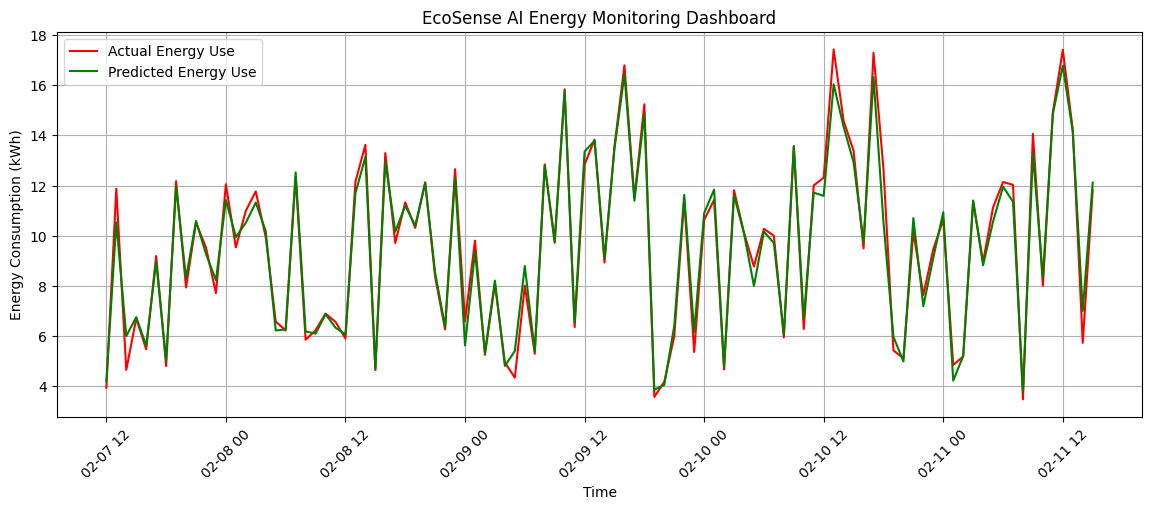

In [11]:
recent_data = df.tail(100)

plt.figure(figsize=(14, 5))

plt.plot(
    recent_data["timestamp"],
    recent_data["energy_kwh"],
    label="Actual Energy Use",
    color="red"
)

plt.plot(
    recent_data["timestamp"],
    recent_data["predicted_energy_kwh"],
    label="Predicted Energy Use",
    color="green"
)

plt.title("EcoSense AI Energy Monitoring Dashboard")
plt.xlabel("Time")
plt.ylabel("Energy Consumption (kWh)")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [12]:
df["potential_saving_kwh"] = df.apply(
    lambda row: row["energy_kwh"] * 0.20
    if row["occupancy"] == 0 and row["energy_kwh"] > 5
    else 0,
    axis=1
)

total_saving = df["potential_saving_kwh"].sum()

# Assumption: 1 kWh saved avoids approximately 0.7 kg CO₂
carbon_reduction = total_saving * 0.7

print(f"Estimated Energy Saving: {total_saving:.2f} kWh")
print(f"Estimated Carbon Reduction: {carbon_reduction:.2f} kg CO₂")

Estimated Energy Saving: 176.38 kWh
Estimated Carbon Reduction: 123.46 kg CO₂


In [14]:
waste_alerts = df[
    (df["occupancy"] == 0) &
    (df["energy_kwh"] > 5)
]

# Calculate potential energy savings
df["potential_saving_kwh"] = df.apply(
    lambda row: row["energy_kwh"] * 0.20
    if row["occupancy"] == 0 and row["energy_kwh"] > 5
    else 0,
    axis=1
)

total_saving = df["potential_saving_kwh"].sum()

# Estimated emissions factor: 0.7 kg CO₂ per kWh saved
carbon_reduction = total_saving * 0.7

print("Energy-waste alerts created:", len(waste_alerts))

Energy-waste alerts created: 104


In [15]:
print("🌿 EcoSense AI — Project Results")
print("-" * 40)
print(f"Model R² Score: {r2:.2f}")
print(f"Model Mean Absolute Error: {mae:.2f} kWh")
print(f"Possible Energy-Waste Alerts: {len(waste_alerts)}")
print(f"Estimated Energy Saving: {total_saving:.2f} kWh")
print(f"Estimated Carbon Reduction: {carbon_reduction:.2f} kg CO₂")

🌿 EcoSense AI — Project Results
----------------------------------------
Model R² Score: 0.94
Model Mean Absolute Error: 0.72 kWh
Possible Energy-Waste Alerts: 104
Estimated Energy Saving: 176.38 kWh
Estimated Carbon Reduction: 123.46 kg CO₂


In [ ]:
df.to_csv("EcoSense_AI_results.csv", index=False)

from google.colab import files
files.download("EcoSense_AI_results.csv")